# Лабораторная работа №2

**Вариант 17**


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["figure.dpi"] = 120

SELECTED_NAMES = ["01.png", "02.png"]

root_candidates = [
    Path.cwd() / "lab2_variant17",
    Path.cwd() / "lab2" / "lab2_variant17",
]

ROOT = next((path for path in root_candidates if (path / "source_png").exists()), root_candidates[0])
SOURCE_DIR = ROOT / "source_png"
GRAY_DIR = ROOT / "gray_bmp"
BINARY_DIR = ROOT / "binary_bmp"

GRAY_DIR.mkdir(parents=True, exist_ok=True)
BINARY_DIR.mkdir(parents=True, exist_ok=True)

for folder in [GRAY_DIR, BINARY_DIR]:
    for old_file in folder.glob("*.bmp"):
        old_file.unlink()

files = [SOURCE_DIR / name for name in SELECTED_NAMES]
missing = [path.name for path in files if not path.exists()]
if missing:
    raise FileNotFoundError(f"Не найдены исходные файлы: {missing}")

print("Используются файлы:", [path.name for path in files])


Используются файлы: ['01.png', '02.png']


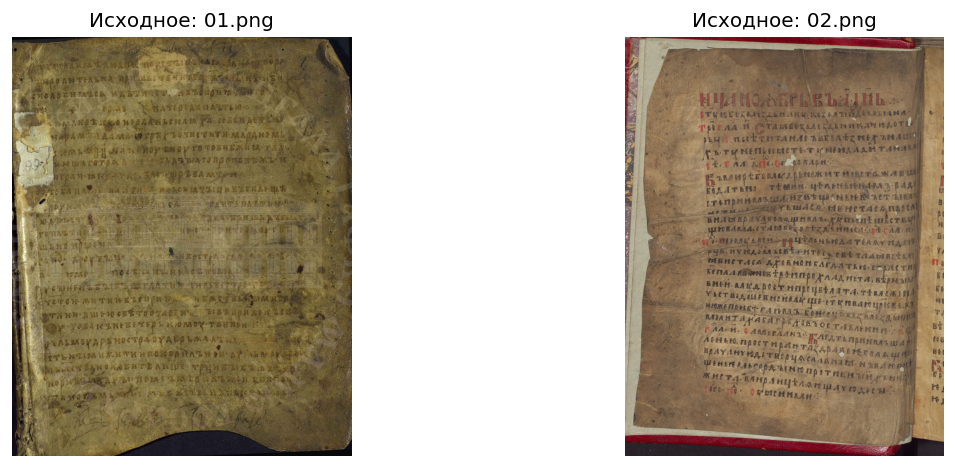

In [2]:
fig, axes = plt.subplots(1, len(files), figsize=(6 * len(files), 4))
if len(files) == 1:
    axes = [axes]

for ax, path in zip(axes, files):
    image = np.array(Image.open(path).convert("RGB"))
    ax.imshow(image)
    ax.set_title(f"Исходное: {path.name}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [3]:
def rgb_to_gray(rgb):
    rgb = rgb.astype(np.float32)
    gray = 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    return np.clip(np.round(gray), 0, 255).astype(np.uint8)


def otsu_threshold(gray):
    hist = np.bincount(gray.ravel(), minlength=256).astype(np.float64)
    prob = hist / hist.sum()
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.arange(256))
    mu_total = mu[-1]
    sigma = (mu_total * omega - mu) ** 2 / (omega * (1.0 - omega) + 1e-12)
    return int(np.argmax(sigma))


def eikvil_binarize(gray, small=5, large=15, diff_limit=15):
    h, w = gray.shape
    out = np.full((h, w), 255, dtype=np.uint8)
    half_large = large // 2

    for y in range(0, h, small):
        for x in range(0, w, small):
            y1, y2 = y, min(y + small, h)
            x1, x2 = x, min(x + small, w)

            cy = (y1 + y2 - 1) // 2
            cx = (x1 + x2 - 1) // 2

            ly1 = max(cy - half_large, 0)
            ly2 = min(cy + half_large + 1, h)
            lx1 = max(cx - half_large, 0)
            lx2 = min(cx + half_large + 1, w)

            large_block = gray[ly1:ly2, lx1:lx2]
            small_block = gray[y1:y2, x1:x2]

            t = otsu_threshold(large_block)

            c1 = large_block[large_block <= t]
            c2 = large_block[large_block > t]

            if len(c1) == 0 or len(c2) == 0:
                out[y1:y2, x1:x2] = 0 if small_block.mean() <= t else 255
                continue

            m1 = float(c1.mean())
            m2 = float(c2.mean())

            if abs(m2 - m1) >= diff_limit:
                out[y1:y2, x1:x2] = np.where(small_block <= t, 0, 255).astype(np.uint8)
            else:
                ms = float(small_block.mean())
                out[y1:y2, x1:x2] = 0 if abs(ms - m1) <= abs(ms - m2) else 255

    return out


In [4]:
processed = []

for path in files:
    rgb = np.array(Image.open(path).convert("RGB"))
    gray = rgb_to_gray(rgb)
    binary = eikvil_binarize(gray, small=5, large=15, diff_limit=15)

    gray_path = GRAY_DIR / f"{path.stem}.bmp"
    bin_path = BINARY_DIR / f"{path.stem}.bmp"

    Image.fromarray(gray, mode="L").save(gray_path)
    Image.fromarray(binary, mode="L").save(bin_path)

    processed.append((path, gray_path, bin_path))

print("Готово:", len(processed))


Готово: 2


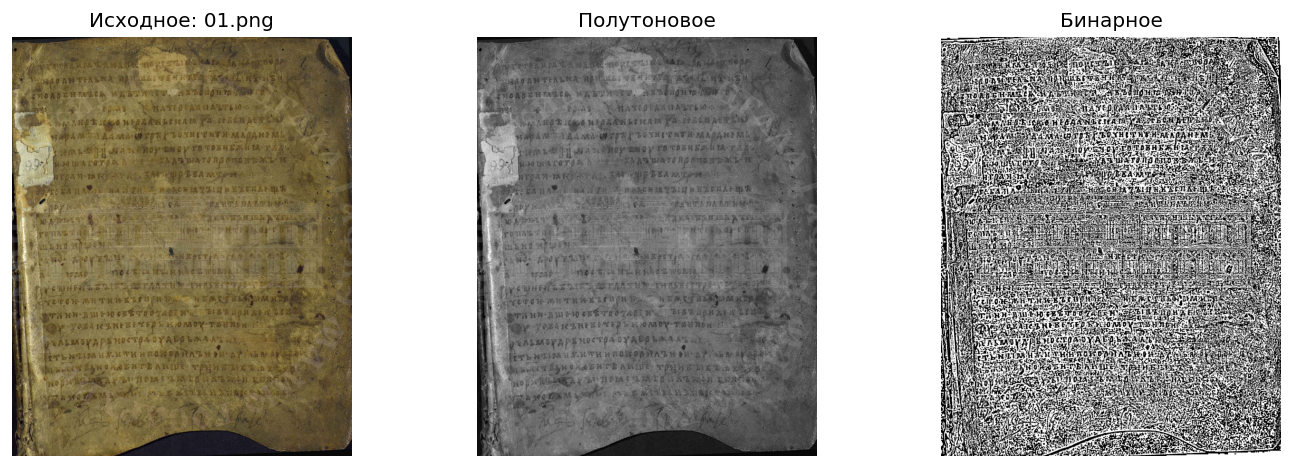

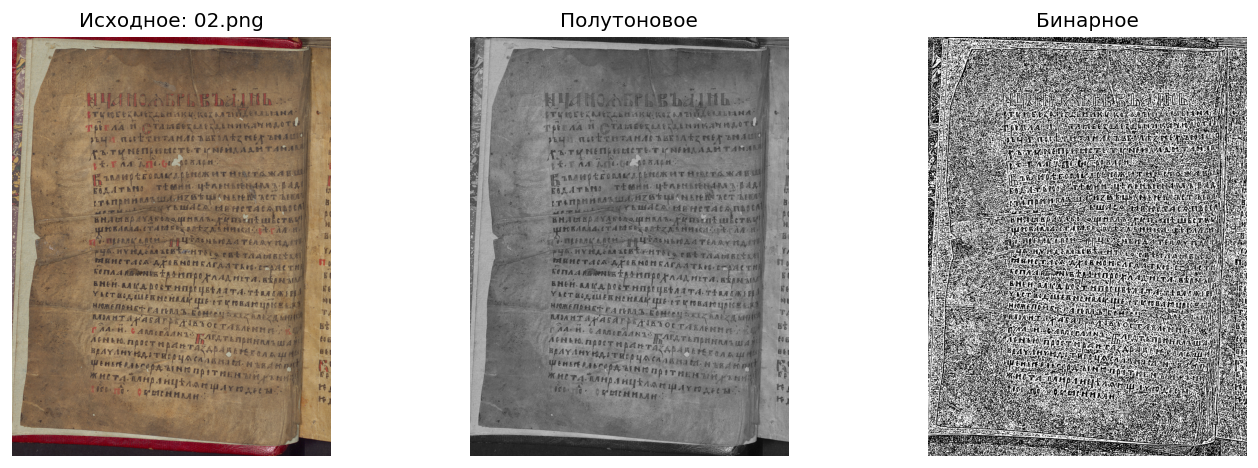

In [5]:
for src_path, gray_path, bin_path in processed:
    src = np.array(Image.open(src_path).convert("RGB"))
    gray = np.array(Image.open(gray_path))
    binary = np.array(Image.open(bin_path))

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    ax[0].imshow(src)
    ax[0].set_title(f"Исходное: {src_path.name}")
    ax[0].axis("off")

    ax[1].imshow(gray, cmap="gray", vmin=0, vmax=255)
    ax[1].set_title("Полутоновое")
    ax[1].axis("off")

    ax[2].imshow(binary, cmap="gray", vmin=0, vmax=255)
    ax[2].set_title("Бинарное")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()
